In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import boxcox
from models import AvaliadorRegressaoParametrica, DiagnosticadorMultinivel

In [27]:
# df_PCA = pd.read_parquet("Dados/fatores_pca_modelo.parquet")
df_PCA = pd.read_parquet("dados_brutos/fatores_pca.parquet")
df_unificado_filtrado = pd.read_parquet(r'Dados/base_de_dados_filtrada.parquet')
base_taxas_de_violencia_2010_2022= pd.read_parquet(r'Dados/taxas_de_violencia_2008_2022.parquet')
base_taxas_de_violencia_2010_2022_filtrada = pd.read_parquet(r'Dados/taxas_de_violencia_2008_2022_filtrada.parquet')

In [28]:
X = df_PCA.iloc[:,1:6]
y = df_PCA.iloc[:,0]

### **0. Instanciando os modelos**

In [29]:
# Instancia o Avaliador (Regra de Negócio: Alpha 0.05)
avaliador_param = AvaliadorRegressaoParametrica(alpha=0.05)
df_PCA_parametrico = df_PCA.copy()

In [30]:
formula_rlm = "TAXA_VIOLENCIA ~ FATOR_POBREZA_DESIGUALDADE + FATOR_INFRAESTRUTURA + FATOR_EDUCACAO + FATOR_EMPREGO + FATOR_POPULACAO"

In [ ]:
# Regressão Linear Multipla
rlm = sm.OLS.from_formula(
    formula=formula_rlm,
    data=df_PCA_parametrico
).fit()

# Regressão Linear Multipla com transformação logaritimica da variável dependente
df_PCA_parametrico_log1 = df_PCA.copy()
df_PCA_parametrico_log1['TAXA_VIOLENCIA'] = np.log1p(df_PCA_parametrico['TAXA_VIOLENCIA'])

log_rlm = sm.OLS.from_formula(
    formula=formula_rlm,
    data=df_PCA_parametrico_log1
).fit()

# Regressão Linear Multipla com transformações de box-cox
df_PCA_parametrico_box = df_PCA.copy()
df_PCA_parametrico_box['TAXA_VIOLENCIA'], lambda_bc = boxcox(df_PCA_parametrico_box['TAXA_VIOLENCIA'] + 1) # +1 para evitar div por 0

# Modelo OLS com fórmula
rlm_bc = sm.OLS.from_formula(
    formula=formula_rlm,
    data=df_PCA_parametrico_box
).fit()

# Regressão Linear Múltipla Multinível com Transformações de Box-Cox
formula_bc = (
    'TAXA_VIOLENCIA ~ FATOR_POBREZA_DESIGUALDADE + FATOR_INFRAESTRUTURA + '
    'FATOR_EDUCACAO + FATOR_EMPREGO + FATOR_POPULACAO'
)

modelo_bc_2niveis = sm.MixedLM.from_formula(
    formula=formula_bc,
    data=df_PCA_parametrico_box,
    groups=df_PCA_parametrico_box["UF"],
    re_formula='1 + FATOR_EMPREGO'
)
resultado_bc_2niveis = modelo_bc_2niveis.fit()

### **1. Regressão Linear Múltipla**


    DIAGNÓSTICO QUANTITATIVO: REGRESSÃO LINEAR MÚLTIPLA     

[1] NORMALIDADE DOS RESÍDUOS

Anderson-Darling: Estatística = 7.144
  > Nível 15.0% -> Valor Crítico = 0.568 | REJEITADO (Não-Normal)
  > Nível 10.0% -> Valor Crítico = 0.647 | REJEITADO (Não-Normal)
  > Nível 5.0% -> Valor Crítico = 0.776 | REJEITADO (Não-Normal)
  > Nível 2.5% -> Valor Crítico = 0.905 | REJEITADO (Não-Normal)
  > Nível 1.0% -> Valor Crítico = 1.077 | REJEITADO (Não-Normal)

Shapiro-Wilk ($W$): Estatística = 0.9096 | p-valor = 0.0000 -> REJEITADO (Não-Normal)
Shapiro-Francia ($W'$): Estatística = 0.9096 | p-valor = 1.4042e-10 -> REJEITADO (Não-Normal)

[2] HOMOCEDASTICIDADE (Breusch-Pagan)
Estatística LM: 9.491 | p-valor: 0.0910
>> Conclusão: Resíduos Homocedásticos (A variância é constante).
------------------------------------------------------------



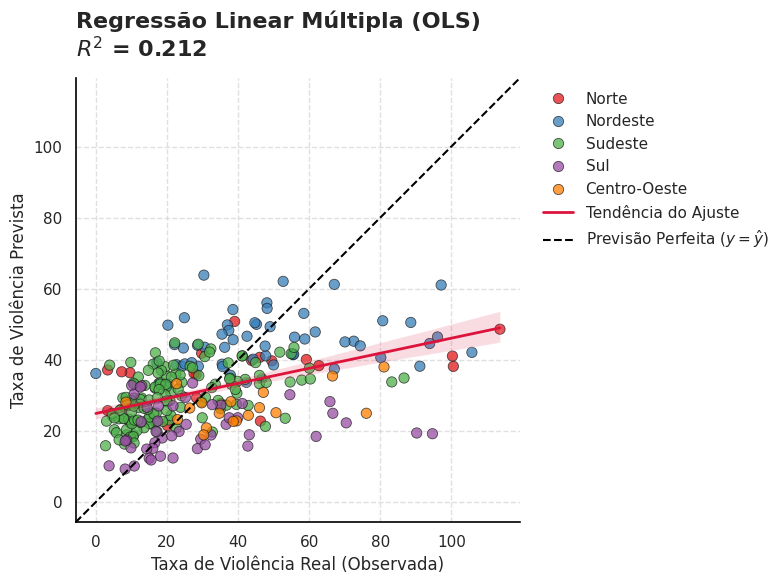

/home/beerserker/Documents/projetos/fatores-violencia-letal/fatores_violencia_letal/lib64/python3.11/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


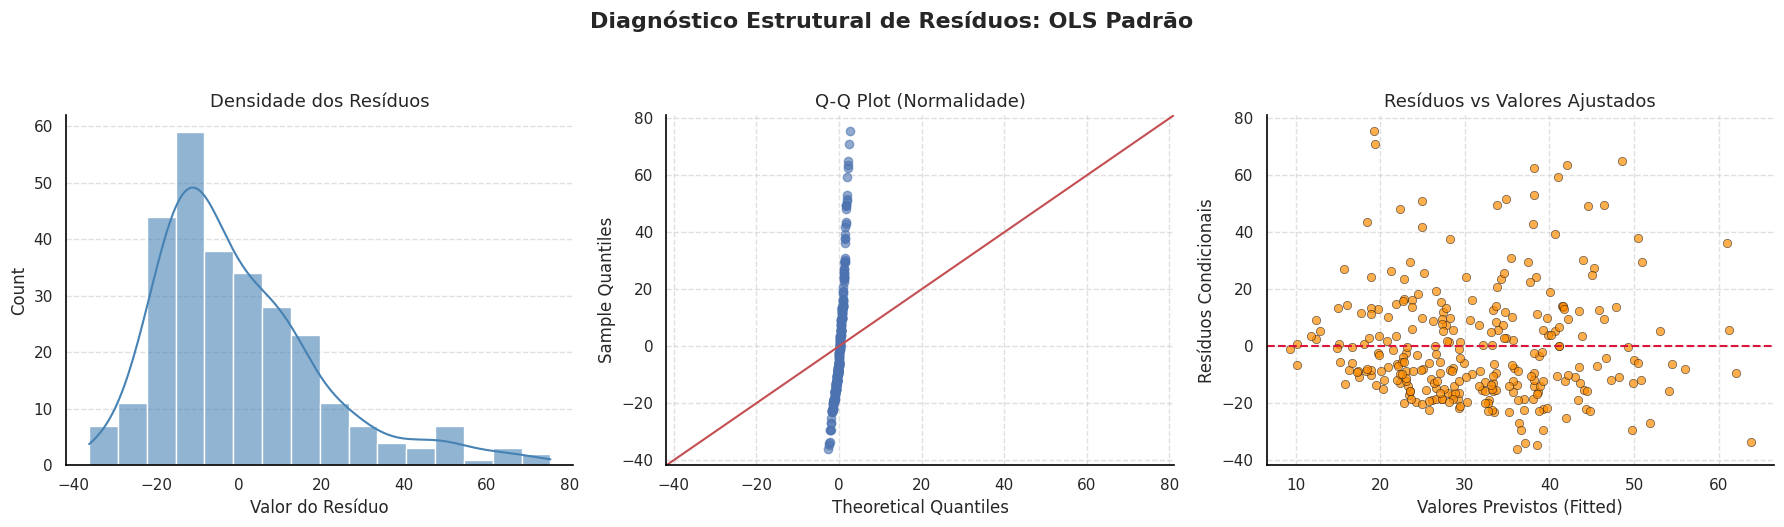

In [7]:
y_real = df_PCA_parametrico['TAXA_VIOLENCIA'].to_numpy()
y_predito_ols = rlm.fittedvalues.to_numpy()
residuos_ols = rlm.resid.to_numpy()
exog_ols = rlm.model.exog # Matriz de variáveis independentes original


avaliador_param.diagnostico_quantitativo(residuos_ols, y_predito_ols, exog=exog_ols, nome_contexto="Regressão Linear Múltipla")
avaliador_param.plotar_previsao_vs_real(y_real, y_predito_ols, hue_labels=df_PCA_parametrico['REGIAO'])
avaliador_param.plotar_painel_residuos(residuos_ols, y_predito_ols, titulo="OLS Padrão")

In [32]:
print(rlm.summary())

                            OLS Regression Results                            
Dep. Variable:         TAXA_VIOLENCIA   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     14.83
Date:                sex, 05 jun 2026   Prob (F-statistic):           6.88e-13
Time:                        14:33:35   Log-Likelihood:                -1245.3
No. Observations:                 282   AIC:                             2503.
Df Residuals:                     276   BIC:                             2524.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### **2. Regressão Linear Múltipla com Transformação Logaritimica**


 DIAGNÓSTICO QUANTITATIVO: REGRESSÃO LINEAR MÚLTIPLA COM TRANSFORMAÇÃO LOGARITIMICA 

[1] NORMALIDADE DOS RESÍDUOS

Anderson-Darling: Estatística = 0.412
  > Nível 15.0% -> Valor Crítico = 0.568 | ACEITO (Normal)
  > Nível 10.0% -> Valor Crítico = 0.647 | ACEITO (Normal)
  > Nível 5.0% -> Valor Crítico = 0.776 | ACEITO (Normal)
  > Nível 2.5% -> Valor Crítico = 0.905 | ACEITO (Normal)
  > Nível 1.0% -> Valor Crítico = 1.077 | ACEITO (Normal)

Shapiro-Wilk ($W$): Estatística = 0.9787 | p-valor = 0.0003 -> REJEITADO (Não-Normal)
Shapiro-Francia ($W'$): Estatística = 0.9756 | p-valor = 1.9737e-04 -> REJEITADO (Não-Normal)

[2] HOMOCEDASTICIDADE (Breusch-Pagan)
Estatística LM: 6.131 | p-valor: 0.2936
>> Conclusão: Resíduos Homocedásticos (A variância é constante).
------------------------------------------------------------



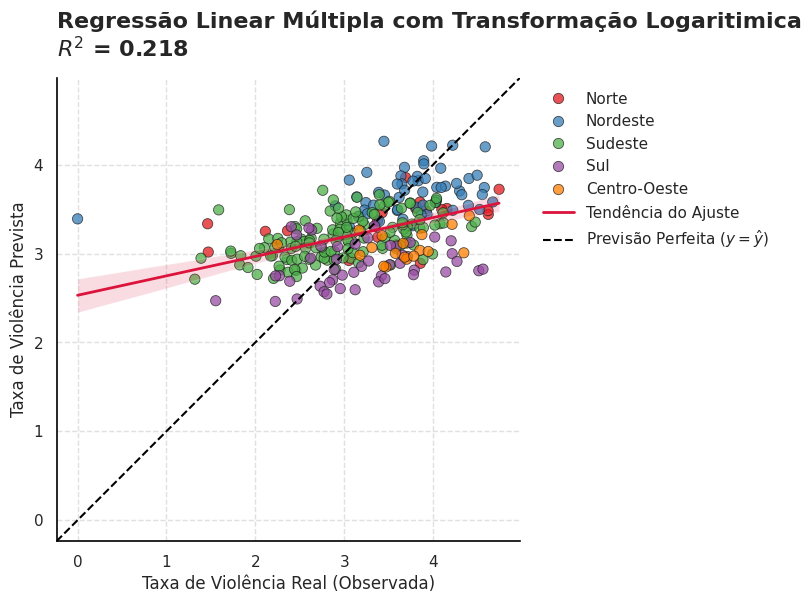

/home/beerserker/Documents/projetos/fatores-violencia-letal/fatores_violencia_letal/lib64/python3.11/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


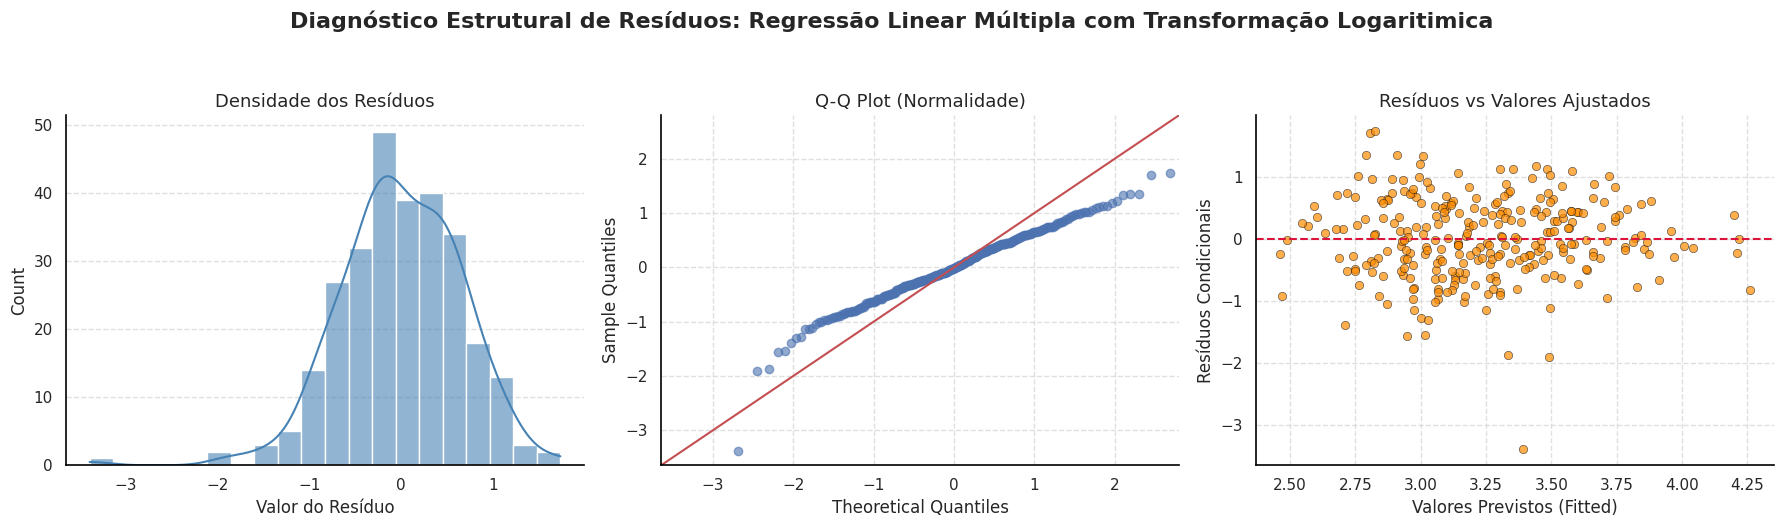

In [33]:
y_real = df_PCA_parametrico_log1['TAXA_VIOLENCIA'].to_numpy()
y_predito_ols = log_rlm.fittedvalues.to_numpy()
residuos_ols = log_rlm.resid.to_numpy()
exog_ols = log_rlm.model.exog # Matriz de variáveis independentes original


avaliador_param.diagnostico_quantitativo(residuos_ols, y_predito_ols, exog=exog_ols, nome_contexto="Regressão Linear Múltipla com transformação logaritimica")
avaliador_param.plotar_previsao_vs_real(y_real, y_predito_ols, hue_labels=df_PCA_parametrico_log1['REGIAO'], titulo='Regressão Linear Múltipla com Transformação Logaritimica')
avaliador_param.plotar_painel_residuos(residuos_ols, y_predito_ols, titulo="Regressão Linear Múltipla com Transformação Logaritimica")

### **3. Regressão Linear Múltipla com Transformações de Box-Cox**


 DIAGNÓSTICO QUANTITATIVO: REGRESSÃO LINEAR MÚLTIPLA COM TRANSFORMAÇÃO LOGARITIMICA 

[1] NORMALIDADE DOS RESÍDUOS

Anderson-Darling: Estatística = 0.532
  > Nível 15.0% -> Valor Crítico = 0.568 | ACEITO (Normal)
  > Nível 10.0% -> Valor Crítico = 0.647 | ACEITO (Normal)
  > Nível 5.0% -> Valor Crítico = 0.776 | ACEITO (Normal)
  > Nível 2.5% -> Valor Crítico = 0.905 | ACEITO (Normal)
  > Nível 1.0% -> Valor Crítico = 1.077 | ACEITO (Normal)

Shapiro-Wilk ($W$): Estatística = 0.9915 | p-valor = 0.1015 -> ACEITO (Normal)
Shapiro-Francia ($W'$): Estatística = 0.9898 | p-valor = 4.4005e-02 -> REJEITADO (Não-Normal)

[2] HOMOCEDASTICIDADE (Breusch-Pagan)
Estatística LM: 6.736 | p-valor: 0.2410
>> Conclusão: Resíduos Homocedásticos (A variância é constante).
------------------------------------------------------------



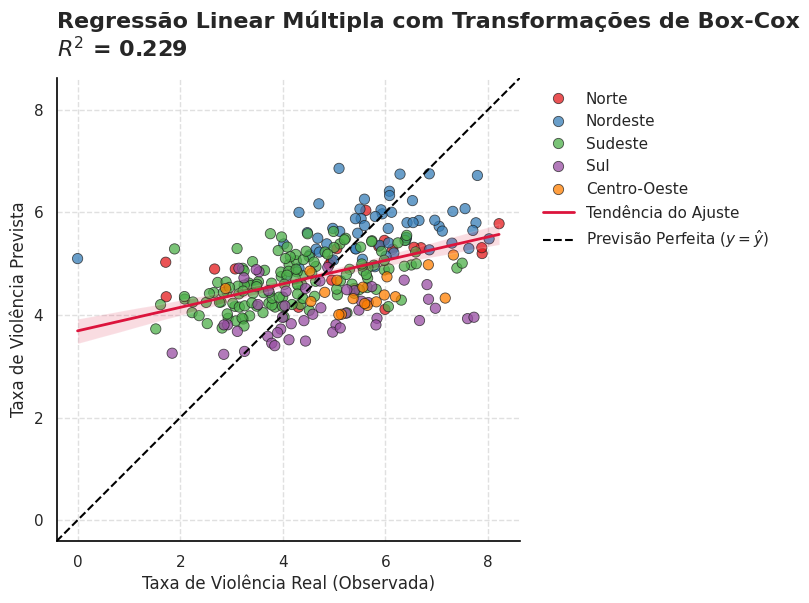

/home/beerserker/Documents/projetos/fatores-violencia-letal/fatores_violencia_letal/lib64/python3.11/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


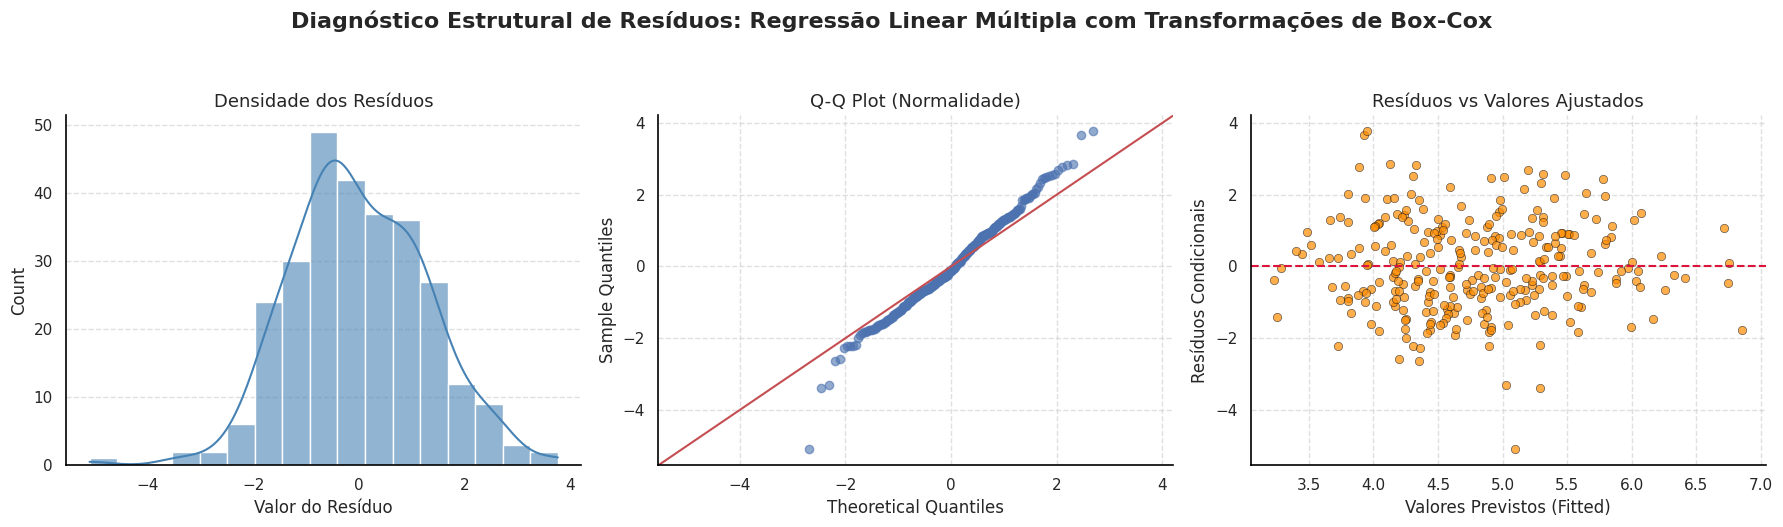

In [35]:
y_real = df_PCA_parametrico_box['TAXA_VIOLENCIA'].to_numpy()
y_predito_ols = rlm_bc.fittedvalues.to_numpy()
residuos_ols = rlm_bc.resid.to_numpy()
exog_ols = rlm_bc.model.exog # Matriz de variáveis independentes original


avaliador_param.diagnostico_quantitativo(residuos_ols, y_predito_ols, exog=exog_ols, nome_contexto="Regressão Linear Múltipla com transformação logaritimica")
avaliador_param.plotar_previsao_vs_real(y_real, y_predito_ols, hue_labels=df_PCA_parametrico_box['REGIAO'], titulo='Regressão Linear Múltipla com Transformações de Box-Cox')
avaliador_param.plotar_painel_residuos(residuos_ols, y_predito_ols, titulo="Regressão Linear Múltipla com Transformações de Box-Cox")

### **4. Regressão Linear Múltipla Multinível com Transformações de Box-Cox**

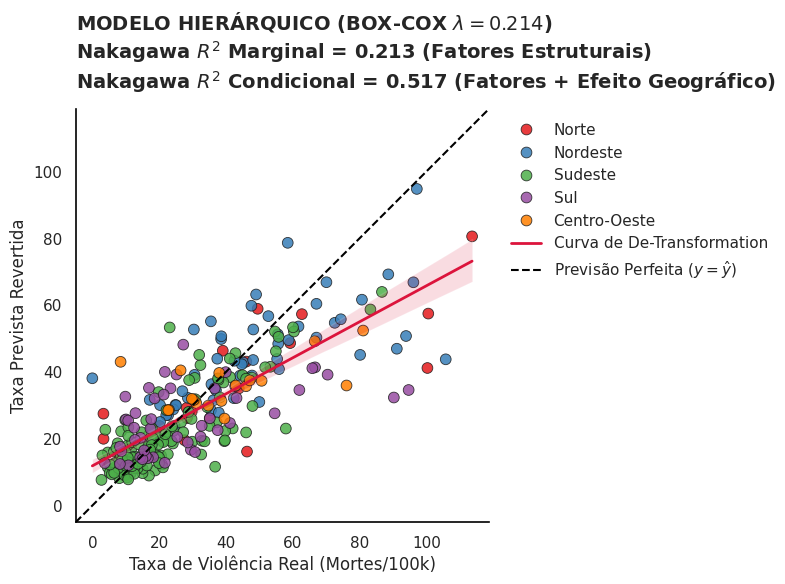

In [36]:
diag_hlm = DiagnosticadorMultinivel()
diag_hlm.renderizar_previsao_boxcox(
    modelo_bc_ajustado=resultado_bc_2niveis,
    df_completo=df_PCA,
    coluna_alvo='TAXA_VIOLENCIA',
    coluna_estrato='REGIAO',
    lambda_bc=lambda_bc
    )


   DIAGNÓSTICO QUANTITATIVO: MODELO HIERÁRQUICO (NÍVEL 1)   

[1] NORMALIDADE DOS RESÍDUOS

Anderson-Darling: Estatística = 2.087
  > Nível 15.0% -> Valor Crítico = 0.568 | REJEITADO (Não-Normal)
  > Nível 10.0% -> Valor Crítico = 0.647 | REJEITADO (Não-Normal)
  > Nível 5.0% -> Valor Crítico = 0.776 | REJEITADO (Não-Normal)
  > Nível 2.5% -> Valor Crítico = 0.905 | REJEITADO (Não-Normal)
  > Nível 1.0% -> Valor Crítico = 1.077 | REJEITADO (Não-Normal)

Shapiro-Wilk ($W$): Estatística = 0.9490 | p-valor = 0.0000 -> REJEITADO (Não-Normal)
Shapiro-Francia ($W'$): Estatística = 0.9447 | p-valor = 6.7281e-08 -> REJEITADO (Não-Normal)

[2] HOMOCEDASTICIDADE (Breusch-Pagan)
Estatística LM: 0.620 | p-valor: 0.4309
>> Conclusão: Resíduos Homocedásticos (A variância é constante).
------------------------------------------------------------


     DIAGNÓSTICO DE NÍVEL 2: EFEITOS ALEATÓRIOS (BLUPs)     

--- Analisando Efeito: [Group] ---
Anderson-Darling : Estatística = 0.401 | Normal? SIM
Shap

/home/beerserker/Documents/projetos/fatores-violencia-letal/models.py:576: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Grupo', y='Efeito', palette=cores, ax=ax)


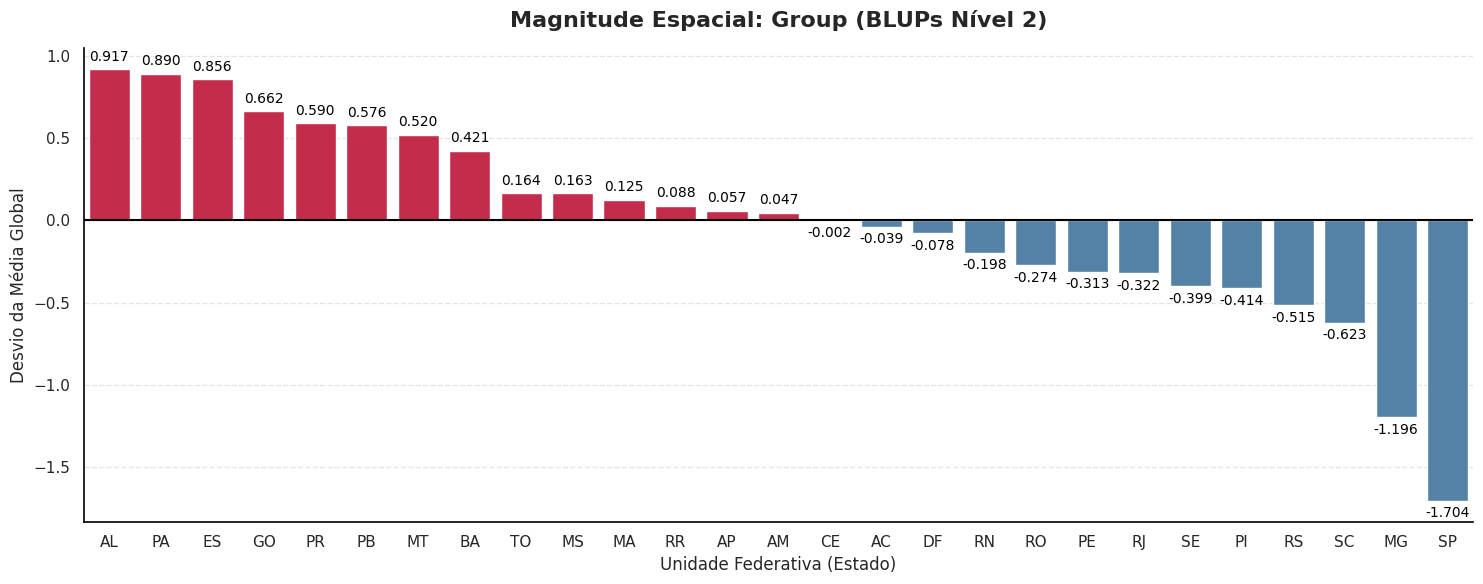


--- Analisando Efeito: [FATOR_EMPREGO] ---
Anderson-Darling : Estatística = 0.871 | Normal? NÃO
Shapiro-Wilk (W) : p-valor = 7.1126e-02 | Normal? SIM
Shapiro-Francia(W'): p-valor = 6.1972e-02 | Normal? SIM


/home/beerserker/Documents/projetos/fatores-violencia-letal/models.py:576: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Grupo', y='Efeito', palette=cores, ax=ax)


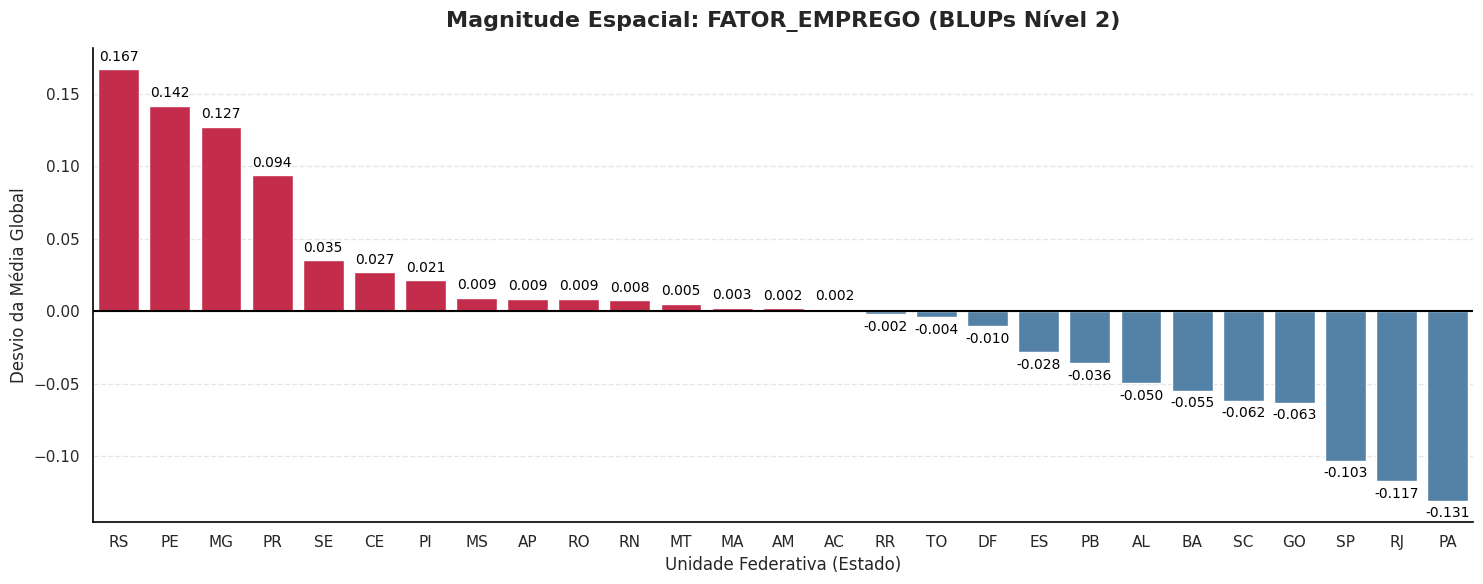

In [ ]:
# -------------------------------------------------------------
# Exemplo 2: MixedLM (Multinível Hierárquico)
# -------------------------------------------------------------
y_predito_bc = resultado_bc_2niveis.fittedvalues.to_numpy()
residuos_bc = resultado_bc_2niveis.resid.to_numpy()
avaliador_param.diagnostico_quantitativo(residuos_bc, y_predito_bc, nome_contexto="Modelo Hierárquico (Nível 1)")
avaliador_param.plotar_painel_residuos(residuos_bc, y_predito_bc, titulo="Multinível Box-Cox (Nível 1)")
avaliador_param.plotar_efeitos_aleatorios_multinivel(resultado_bc_2niveis.random_effects)
diag_hlm.diagnostico_efeitos_aleatorios_blups(modelo_ajustado=resultado_bc_2niveis, alpha=0.05)


In [38]:
print(resultado_bc_2niveis.summary())

                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    TAXA_VIOLENCIA
No. Observations:    282        Method:                REML          
No. Groups:          27         Scale:                 0.9707        
Min. group size:     1          Log-Likelihood:        -425.6082     
Max. group size:     74         Converged:             Yes           
Mean group size:     10.4                                            
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   5.293    0.181 29.182 0.000  4.938  5.649
FATOR_POBREZA_DESIGUALDADE -0.098    0.078 -1.262 0.207 -0.251  0.054
FATOR_INFRAESTRUTURA        0.173    0.072  2.394 0.017  0.031  0.315
FATOR_EDUCACAO             -0.157    0.053 -2.929 0.003 -0.261 -0.052
FATOR_EMPREGO              -0.928   